# 01 — Data Loading and Validation

This notebook is the first of three notebooks in the pairs trading research pipeline. Its scope is limited to data loading, data validation, diagnostics inspection, and basic visualization of the loaded price matrix.

The notebook calls the project’s Python modules rather than duplicating logic inside notebook cells. Specifically, it uses the data loading and validation functions defined in `src/` to fetch historical price data, validate the resulting price matrix, inspect diagnostics, save processed data for downstream notebooks, and plot normalized prices.

The full project notebook flow is:

1. `01_data_loading_validation.ipynb` — load and validate market data.
2. `02_spread_modeling.ipynb` — compute log prices, hedge model, spread, and z-score.
3. `03_backtest_report.ipynb` — run backtest logic and summarize performance metrics.

This notebook has 8 sections as follows:

 1. Project Setup and Imports

In [8]:
from pathlib import Path
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import fetch_tiingo_price_matrix

print(PROJECT_ROOT)

c:\Users\Aditi\Aditi_Workspaces\VSCode\QuantProjects\pairs-trading-ai-tech


2. Load Environment variables

In [9]:
load_dotenv(PROJECT_ROOT / ".env")
api_key = os.getenv("TIINGO_API_KEY")

3. Define tickers and date range. AAPL and MSFT are used as an initial large-cap technology pair for pipeline demonstration. Pair choice is illustrative in v1; later versions can add systematic pair selection using correlation, cointegration, sector grouping, and stability checks.

In [10]:
tickers=tickers = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN",
    "NVDA", "ADBE", "CRM", "ORCL", "INTC"
]
start_date = '2020-01-01'
end_date = '2024-12-31'
price_field = 'adjClose'

4. Fetch prices using fetch_tiingo_price_matrix()

In [13]:
price_matrix, loader_diagnostics = fetch_tiingo_price_matrix(tickers,start_date,end_date,api_key=api_key,price_field=price_field,validate=True)

5. Inspect price matrix

In [14]:
price_matrix.head()

,AAPL,MSFT,GOOGL,META,AMZN,NVDA,ADBE,CRM,ORCL,INTC
date,,,,,,,,,,
2020-01-02 00:00:00+00:00,72.339604,151.817457,67.870106,208.162430,94.9005,5.964042,334.43,164.537517,49.159296,53.666888
2020-01-03 00:00:00+00:00,71.636319,149.927064,67.515056,207.060989,93.7485,5.868582,331.81,163.729560,48.986167,53.014135
2020-01-06 00:00:00+00:00,72.207136,150.314595,69.314604,210.960685,95.1440,5.893193,333.71,170.902643,49.241304,52.864178
2020-01-07 00:00:00+00:00,71.867536,148.944060,69.180717,211.417138,95.3430,5.964539,333.39,173.415192,49.350648,51.982079
2020-01-08 00:00:00+00:00,73.023621,151.316503,69.673126,213.560483,94.5985,5.975726,337.87,174.725659,49.542000,52.017363


In [15]:
price_matrix.shape

(1258, 10)

6. Inspect loader diagnostics

In [16]:
print(loader_diagnostics.keys())

dict_keys(['data_source', 'tickers_requested', 'start_date', 'end_date', 'price_field', 'data_loader_checks_passed', 'ticker_loader_diagnostics', 'matrix_summary', 'validation_was_run', 'validation_diagnostics'])


In [18]:
print("Data Loader Checks:-",loader_diagnostics['data_loader_checks_passed'])
print("Price Matrix Statistics:-",loader_diagnostics['matrix_summary'])
print("Price Matrix Validation:-",loader_diagnostics['validation_diagnostics'])

Data Loader Checks:- ['API key check passed.', 'Tickers list check passed.', 'Tickers type check passed.', 'Each ticker is a string check passed.', 'Each ticker is not an empty string check passed.', 'Start date and end date presence check passed.', 'Start date and end date are convertible.', 'Start date is less than end date.', 'Validate parameter type check passed.', 'Price matrix created.', 'Price matrix sorted by date.', 'Price matrix validation applied.']
Price Matrix Statistics:- {'num_observations': 1258, 'num_assets': 10, 'start_date': Timestamp('2020-01-02 00:00:00+0000', tz='UTC'), 'end_date': Timestamp('2024-12-31 00:00:00+0000', tz='UTC'), 'asset_list': ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN', 'NVDA', 'ADBE', 'CRM', 'ORCL', 'INTC']}
Price Matrix Validation:- {'is_valid': True, 'num_observations': 1258, 'num_assets': 10, 'start_date': Timestamp('2020-01-02 00:00:00+0000', tz='UTC'), 'end_date': Timestamp('2024-12-31 00:00:00+0000', tz='UTC'), 'missing_fraction_by_asset': {'

In [19]:
print("Ticker Diagnostics:-",pd.DataFrame(loader_diagnostics['ticker_loader_diagnostics']))

Ticker Diagnostics:-   ticker  tiingo_request_successful  data_not_empty  date_column_present  \
0   AAPL                       True            True                 True   
1   MSFT                       True            True                 True   
2  GOOGL                       True            True                 True   
3   META                       True            True                 True   
4   AMZN                       True            True                 True   
5   NVDA                       True            True                 True   
6   ADBE                       True            True                 True   
7    CRM                       True            True                 True   
8   ORCL                       True            True                 True   
9   INTC                       True            True                 True   

   price_field_present  date_column_converted  price_series_extracted  \
0                 True                   True                    True

7. Save price_matrix to data/processed

In [40]:
#Define filepath
file_path = PROJECT_ROOT/f"data/processed/price_matrix_tech_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"

#Ensure that the directory exists
os.makedirs(os.path.dirname(file_path), exist_ok=True)

#Save the DataFrame
price_matrix.to_csv(file_path, index=True, encoding='utf-8')

8. Plot normalized prices.

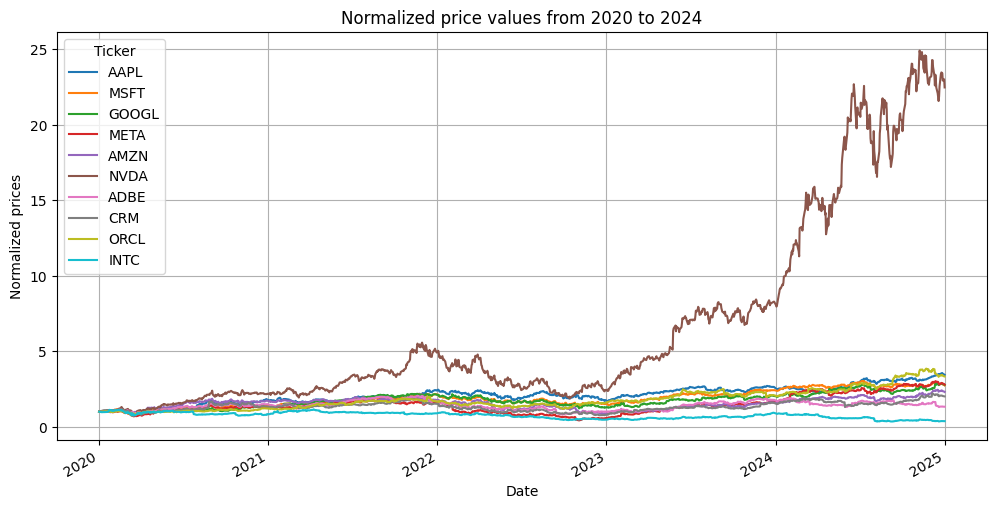

In [39]:
normalized_prices = price_matrix/price_matrix.iloc[0]
normalized_prices.plot(figsize=(12,6))
plt.title('Normalized price values from 2020 to 2024')
plt.xlabel('Date')
plt.ylabel('Normalized prices')
plt.legend(title="Ticker")
plt.grid(True)
plt.show()


The notebook is intentionally kept thin: core logic is implemented in `src/data_loader.py` and `src/data_validator.py`, while this notebook demonstrates usage and inspects outputs.